<a href="https://colab.research.google.com/github/LaliChicken/FinRL-PPO-Trading-Agent/blob/main/FinRL-Trading-Bot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


FinRL Day Trading Bot - SPY Options / Equity
--------------------------------------------
Author: Yusuf Guler; Rahul Ghosh

Date: March 2026

Description:

    Trains a Reinforcement Learning agent (PPO) using FinRL and Stable Baselines3
    to trade around high-impact news events. Uses Alpaca API for historical data.
    Runs locally with CUDA-enabled PyTorch.


In [1]:
import pandas as pd
import os

# Re-listing files to debug path issues
print("Current working directory:", os.getcwd())
print("Files in current directory:", os.listdir('.'))

csv_files = [
    '/content/anaconda_projects_3b45729b-5216-4ca7-963f-ec41f5e53df7_holdout_account_value (1).csv',
    '/content/anaconda_projects_3b45729b-5216-4ca7-963f-ec41f5e53df7_holdout_actions (1).csv',
    '/content/anaconda_projects_3b45729b-5216-4ca7-963f-ec41f5e53df7_holdout_signals (1).csv'
]

for file_path in csv_files:
    if os.path.exists(file_path):
        print(f"\nLoading {file_path}...")
        try:
            df = pd.read_csv(file_path)
            print(df.head())
            print(df.info())
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
    else:
        print(f"File not found: {file_path}")

Current working directory: /content
Files in current directory: ['.config', 'anaconda_projects_3b45729b-5216-4ca7-963f-ec41f5e53df7_ppo_spy_5m (1).zip', 'anaconda_projects_3b45729b-5216-4ca7-963f-ec41f5e53df7_holdout_account_value (1).csv', 'anaconda_projects_3b45729b-5216-4ca7-963f-ec41f5e53df7_holdout_actions (1).csv', 'anaconda_projects_3b45729b-5216-4ca7-963f-ec41f5e53df7_holdout_signals (1).csv', 'sample_data']

Loading /content/anaconda_projects_3b45729b-5216-4ca7-963f-ec41f5e53df7_holdout_account_value (1).csv...
                        date  account_value
0  2025-12-01 08:00:00-05:00       100000.0
1  2025-12-01 08:10:00-05:00       100000.0
2  2025-12-01 08:15:00-05:00       100000.0
3  2025-12-01 08:20:00-05:00       100000.0
4  2025-12-01 08:25:00-05:00       100000.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3233 entries, 0 to 3232
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date       

In [2]:
%pip install websockets>=13.0 --upgrade
%pip install git+https://github.com/AI4Finance-Foundation/FinRL.git
%pip uninstall -y alpaca-trade-api
%pip install yfinance
%pip install stable-baselines3
%pip install alpaca-trade-api
%pip install stockstats
%pip install exchange_calendars

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio-client 1.14.0 requires websockets<16.0,>=13.0, but you have websockets 16.0 which is incompatible.
google-adk 1.26.0 requires websockets<16.0.0,>=15.0.1, but you have websockets 16.0 which is incompatible.
  Cloning https://github.com/AI4Finance-Foundation/FinRL.git to /tmp/pip-req-build-t__qpvv_
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Finance-Foundation/FinRL.git /tmp/pip-req-build-t__qpvv_
  Resolved https://github.com/AI4Finance-Foundation/FinRL.git to commit f4283de63ca73c915321c5555fa3751698a61eec
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/AI4Finance-Foundation/ElegantRL.git to /tmp/pip-install-dulre0_g/elegantrl_c6740d6644634f07be879ff89b5be14c
 

In [3]:
import yfinance as yf
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer
from finrl.config_tickers import DOW_30_TICKER
from finrl.config import INDICATORS

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

In [53]:

# Define constants

TRAIN_START_DATE = '2010-01-01'
TRAIN_END_DATE = '2024-01-01'

ticker_list = DOW_30_TICKER
print(f"Downloading data for {len(ticker_list)} tickers: {ticker_list}")

print("Fetching data...")
df_raw = YahooDownloader(start_date=TRAIN_START_DATE,
                         end_date=TRAIN_END_DATE,
                         ticker_list=ticker_list).fetch_data()

print(f"Raw data shape: {df_raw.shape}")

# Define constants
TRAIN_START_DATE = '2010-01-01'
TRAIN_END_DATE = '2024-01-01'

ticker_list = DOW_30_TICKER
print(f"Downloading data for {len(ticker_list)} tickers: {ticker_list}")

print("Fetching data...")
try:
    df_raw = YahooDownloader(start_date=TRAIN_START_DATE,
                             end_date=TRAIN_END_DATE,
                             ticker_list=ticker_list).fetch_data()

    print(f"Raw data shape: {df_raw.shape}")
    print(df_raw.head())

    print("Preprocessing data...")
    fe = FeatureEngineer(
                        use_technical_indicator=True,
                        tech_indicator_list=INDICATORS,
                        use_vix=True,
                        use_turbulence=True,
                        user_defined_feature=False)

    processed_df = fe.preprocess_data(df_raw)

    # Quick Check
    print(f"Processed data shape: {processed_df.shape}")
    print(processed_df.head())

except Exception as e:
    print(f"An error occurred: {e}")
    # Fallback
    print("Attempting direct yfinance download as fallback...")
    data = yf.download(ticker_list, start=TRAIN_START_DATE, end=TRAIN_END_DATE)
    print("Direct download shape:", data.shape)

[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for re

Fetching data...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return dateti

Shape of DataFrame:  (99821, 8)
Raw data shape: (99821, 8)
Fetching data...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return dateti

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Successfully added technical indicators
Shape of DataFrame:  (3521, 8)
Successfully added vix


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Successfully added turbulence index
Processed data shape: (98588, 18)
         date      close       high        low       open     volume   tic  \
0  2010-01-04   6.412384   6.427066   6.363544   6.395005  493729600  AAPL   
1  2010-01-04  39.041157  39.142614  38.256546  38.303893    5277400  AMGN   
2  2010-01-04  32.483326  32.626215  32.062600  32.396008    6894300   AXP   
3  2010-01-04  43.777557  43.941197  42.702209  43.419109    6186700    BA   
4  2010-01-04  39.198868  39.627343  38.502594  38.596325    7325600   CAT   

   day  macd   boll_ub  boll_lb  rsi_30     cci_30  dx_30  close_30_sma  \
0    0   0.0  6.433602  6.40225   100.0  66.666667  100.0      6.412384   
1    0   0.0  6.433602  6.40225   100.0  66.666667  100.0     39.041157   
2    0   0.0  6.433602  6.40225   100.0  66.666667  100.0     32.483326   
3    0   0.0  6.433602  6.40225   100.0  66.666667  100.0     43.777557   
4    0   0.0  6.433602  6.40225   100.0  66.666667  100.0     39.198868   

   close_6

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [54]:
from finrl.meta.preprocessor.preprocessors import data_split
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

# Training data: 2020-01-01 to 2022-01-01
# Validation/Trading data: 2022-01-01 to 2023-01-01
train = data_split(processed_df, '2012-01-01', '2022-01-01')
trade = data_split(processed_df, '2022-01-01', '2023-01-01')
print(f"Training Data Shape: {train.shape}")
print(f"Trading Data Shape: {trade.shape}")

# Define Environment Parameters
stock_dimension = len(train.tic.unique())
state_space = 1 + 2*stock_dimension + len(INDICATORS)*stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

buy_cost_list = sell_cost_list = [0.001] * stock_dimension
num_stock_shares = [0] * stock_dimension

env_kwargs = {
    "hmax": 1000,
    "initial_amount": 1000000,
    "num_stock_shares": num_stock_shares,
    "buy_cost_pct": buy_cost_list,
    "sell_cost_pct": sell_cost_list,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4
}

# Initialize Training Environment
e_train_gym = StockTradingEnv(df=train, **env_kwargs)

# Reset Environment to verify
env_train, _ = e_train_gym.reset()
print("Environment initialized successfully.")

Training Data Shape: (70476, 18)
Trading Data Shape: (7028, 18)
Stock Dimension: 28, State Space: 281
Environment initialized successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [58]:
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent


# We use the 'train' dataframe and 'env_kwargs' defined in previous steps
print("Re-instantiating StockTradingEnv...")
e_train_gym = StockTradingEnv(df=train, **env_kwargs)

# IMPORTANT: Pass the environment object 'e_train_gym', NOT the result of reset()
agent = DRLAgent(env=e_train_gym)

# Hyperparameters
PPO_PARAMS = {
    "n_steps": 4096,
    "ent_coef": 0.01,
    "learning_rate": 0.00025,
    "batch_size": 128,
}

# Create Model
print("Creating PPO model...")
model_ppo = agent.get_model("ppo", model_kwargs=PPO_PARAMS)

# Train Model
print("Training PPO Agent...")
trained_ppo = agent.train_model(model=model_ppo,
                                tb_log_name="ppo",
                                total_timesteps=10000)

# Save Model
trained_ppo.save("trained_ppo_model.zip")
print("Training complete. Model saved as 'trained_ppo_model.zip'.")

Re-instantiating StockTradingEnv...
Creating PPO model...
{'n_steps': 4096, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 128}
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training PPO Agent...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


------------------------------------
| rollout/           |             |
|    ep_len_mean     | 2.52e+03    |
|    ep_rew_mean     | 42.3        |
| time/              |             |
|    fps             | 118         |
|    iterations      | 1           |
|    time_elapsed    | 34          |
|    total_timesteps | 4096        |
| train/             |             |
|    reward          | -1.0509522  |
|    reward_max      | 11.422779   |
|    reward_mean     | 0.029764032 |
|    reward_min      | -16.632437  |
------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 2.52e+03    |
|    ep_rew_mean          | 82.3        |
| time/                   |             |
|    fps                  | 116         |
|    iterations           | 2           |
|    time_elapsed         | 70          |
|    total_timesteps      | 8192        |
| train/                  |             |
|    approx_kl            | 0.020451106 |
|    clip_fraction        | 0.213       |
|    clip_range           | 0.2         |
|    entropy_loss         | -39.8       |
|    explained_variance   | -0.0169     |
|    learning_rate        | 0.00025     |
|    loss                 | 3.69        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0456     |
|    reward               | -0.5283495  |
|    reward_max           | 15.290012   |
|    reward_mean          | 0.039076954 |
|    reward_min           | -24.120554  |
|    std                  | 1     

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 2.52e+03    |
|    ep_rew_mean          | 96          |
| time/                   |             |
|    fps                  | 115         |
|    iterations           | 3           |
|    time_elapsed         | 106         |
|    total_timesteps      | 12288       |
| train/                  |             |
|    approx_kl            | 0.02054656  |
|    clip_fraction        | 0.221       |
|    clip_range           | 0.2         |
|    entropy_loss         | -39.9       |
|    explained_variance   | -0.0023     |
|    learning_rate        | 0.00025     |
|    loss                 | 9.12        |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.0378     |
|    reward               | -3.1674953  |
|    reward_max           | 15.69814    |
|    reward_mean          | 0.03183801  |
|    reward_min           | -15.8556385 |
|    std                  | 1.01  

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Training complete. Model saved as 'trained_ppo_model.zip'.


In [59]:
from finrl.agents.stablebaselines3.models import DRLAgent
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv

print("Initializing Backtesting Environment...")
e_trade_gym = StockTradingEnv(df=trade, **env_kwargs)

print("Running Backtest...")
df_account_value, df_actions = DRLAgent.DRL_prediction(
    model=trained_ppo,
    environment=e_trade_gym
)

print("Backtest Complete.")
print(f"Account Value Shape: {df_account_value.shape}")
print(df_account_value.head())
print(f"Actions Shape: {df_actions.shape}")
print(df_actions.head())

Initializing Backtesting Environment...
Running Backtest...
hit end!
Backtest Complete.
Account Value Shape: (251, 2)
         date  account_value
0  2022-01-03   1.000000e+06
1  2022-01-04   1.000287e+06
2  2022-01-05   9.990130e+05
3  2022-01-06   9.947577e+05
4  2022-01-07   9.944183e+05
Actions Shape: (250, 28)
            AAPL  AMGN  AXP  BA  CAT  CRM  CSCO  CVX  DIS  GS  ...  MMM  MRK  \
date                                                           ...             
2022-01-03    46     0   52  63    0    0    62    0    0  17  ...    0   79   
2022-01-04    46     0   52  63    0    0    62    0    0  17  ...    0   79   
2022-01-05    46     0   52  63    0    0    62    0    0  17  ...    0   79   
2022-01-06    46     0   52  63    0    0    62    0    0  17  ...    0   79   
2022-01-07    46     0   52  63    0    0    62    0    0  17  ...    0   79   

            MSFT  NKE  PG  TRV  UNH  V  VZ  WMT  
date                                             
2022-01-03     0    0 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [60]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure date is datetime
df_account_value['date'] = pd.to_datetime(df_account_value['date'])

initial_value = df_account_value['account_value'].iloc[0]
final_value = df_account_value['account_value'].iloc[-1]
total_return = ((final_value - initial_value) / initial_value) * 100

print(f"Initial Portfolio Value: ${initial_value:,.2f}")
print(f"Final Portfolio Value:   ${final_value:,.2f}")
print(f"Total Cumulative Return: {total_return:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(df_account_value['date'], df_account_value['account_value'], label='Agent Account Value', color='blue')
plt.title(f'Backtest Performance (Total Return: {total_return:.2f}%)')
plt.xlabel('Date')
plt.ylabel('Account Value ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Initial Portfolio Value: $1,000,000.00
Final Portfolio Value:   $1,048,541.40
Total Cumulative Return: 4.85%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [64]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure date is datetime
df_account_value['date'] = pd.to_datetime(df_account_value['date'])

initial_value = df_account_value['account_value'].iloc[0]
final_value = df_account_value['account_value'].iloc[-1]
total_return = ((final_value - initial_value) / initial_value) * 100

print(f"Initial Portfolio Value: ${initial_value:,.2f}")
print(f"Final Portfolio Value:   ${final_value:,.2f}")
print(f"Total Cumulative Return: {total_return:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(df_account_value['date'], df_account_value['account_value'], label='Agent Account Value', color='blue')
plt.title(f'Backtest Performance (Total Return: {total_return:.2f}%)')
plt.xlabel('Date')
plt.ylabel('Account Value ($)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

#Save plot - check folder
plt.savefig("backtest_performance.png", dpi=1000)
print("Plot saved as backtest_performance.png")

Initial Portfolio Value: $1,000,000.00
Final Portfolio Value:   $1,048,541.40
Total Cumulative Return: 4.85%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Plot saved as backtest_performance.png


In [62]:
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame
import pandas as pd

def get_live_data_chunked(tickers, start_time, end_time):
    """
    Fetches minute data for a list of tickers.
    """
    request_params = StockBarsRequest(
        symbol_or_symbols=tickers,
        timeframe=TimeFrame.Minute,
        start=start_time,
        end=end_time
    )
    try:
        bars = client.get_stock_bars(request_params)
        df = bars.df
        df = df.reset_index()
        return df
    except Exception as e:
        print(f"Error fetching data: {e}")
        return pd.DataFrame()


def process_live_data_finrl(df_minute, required_tickers):
    """
    Resamples minute data to 5-minute candles for multiple tickers and formats for FinRL.
    Uses Forward Fill to ensure all tickers exist at all timestamps.
    """
    if df_minute.empty:
        return pd.DataFrame()

    df_minute['timestamp'] = pd.to_datetime(df_minute['timestamp'])

    agg_dict = {
        'open': 'first',
        'high': 'max',
        'low': 'min',
        'close': 'last',
        'volume': 'sum'
    }

    def resample_group(x):
        x = x.set_index('timestamp')
        return x.resample('5min').agg(agg_dict)

    df_5m = df_minute.groupby('symbol').apply(resample_group).reset_index()


    df_pivot = df_5m.pivot(index='timestamp', columns='symbol')

    df_pivot = df_pivot.ffill()

    df_pivot = df_pivot.bfill()

    df_aligned = df_pivot.stack().reset_index()

    df_aligned = df_aligned[df_aligned['symbol'].isin(required_tickers)]

    df_aligned.rename(columns={'timestamp': 'date', 'symbol': 'tic'}, inplace=True)

    df_aligned['date'] = df_aligned['date'].dt.strftime('%Y-%m-%d %H:%M:%S')

    return df_aligned


from google.colab import userdata
from datetime import datetime, timezone, timedelta
import numpy as np
from finrl.meta.preprocessor.preprocessors import FeatureEngineer
from finrl.config import INDICATORS
from alpaca.data.historical import StockHistoricalDataClient

print("Authenticating with Alpaca...")
API_KEY = userdata.get('API_KEY')
API_SECRET = userdata.get('API_SECRET')
client = StockHistoricalDataClient(API_KEY, API_SECRET)

try:
    live_tickers = train.tic.unique().tolist()
    print(f"Model expects {len(live_tickers)} tickers (from training data).")
except NameError:
    print("Error: 'train' dataframe not found. Cannot determine correct tickers.")
    live_tickers = []

if live_tickers:
    NOW = datetime.now(timezone.utc)
    END_TIME = NOW - timedelta(minutes=16)
    RECENT_START = END_TIME - timedelta(days=5)

    print(f"Pulling live data from {RECENT_START.strftime('%Y-%m-%d')} to {END_TIME.strftime('%H:%M')}...")

    live_raw = get_live_data_chunked(live_tickers, RECENT_START, END_TIME)

    if live_raw.empty:
        print("WARNING: No live data pulled. Market closed or API error.")
    else:

        live_5m = process_live_data_finrl(live_raw, live_tickers)

        print("Calculating technical indicators...")
        live_fe_processor = FeatureEngineer(
                        use_technical_indicator=True,
                        tech_indicator_list=INDICATORS,
                        use_vix=False,
                        use_turbulence=False,
                        user_defined_feature=False)

        live_fe = live_fe_processor.preprocess_data(live_5m).dropna().reset_index(drop=True)

        tic_counts = live_fe.groupby('date')['tic'].count()
        expected_tickers = len(live_tickers)
        valid_dates = tic_counts[tic_counts == expected_tickers].index

        print(f"Filtering data: Keeping {len(valid_dates)}/{len(tic_counts)} timestamps with complete data for all {expected_tickers} tickers.")

        live_fe = live_fe[live_fe['date'].isin(valid_dates)].copy()

        if live_fe.empty:
            print("ERROR: No timestamps have data for all required tickers. Inference aborted.")
        else:
            live_fe = live_fe.sort_values(by=['date', 'tic'])


            date_codes, unique_dates = pd.factorize(live_fe['date'])
            live_fe.index = date_codes

            env_live = StockTradingEnv(
                df=live_fe,
                **env_kwargs
            )

            print("Consulting the neural network...")
            _ = DRLAgent.DRL_prediction(model=trained_ppo, environment=env_live)

            print("\n" + "="*30)
            print("CONSULTING ORACLE FOR RAW SENSITIVITY...")

            last_date = live_fe['date'].iloc[-1]
            df_last_state = live_fe[live_fe['date'] == last_date].copy()


            df_last_state.index = [0] * len(df_last_state)

            env_inference = StockTradingEnv(df=df_last_state, **env_kwargs)

            obs_res = env_inference.reset()
            if isinstance(obs_res, tuple):
                obs = obs_res[0]
            else:
                obs = obs_res

            raw_actions, _ = trained_ppo.predict(obs, deterministic=True)

            tickers = df_last_state['tic'].values

            df_raw = pd.DataFrame({
                'ticker': tickers,
                'raw_strength': raw_actions
            })

            print(f"LIVE MARKET TIMESTAMP: {last_date}")
            print("="*30)

            print("Top 5 Bullish Inclinations (Raw Model Output):")
            bullish = df_raw.sort_values(by='raw_strength', ascending=False).head(5)
            print(bullish)

            print("\nTop 5 Bearish Inclinations (Raw Model Output):")
            bearish = df_raw.sort_values(by='raw_strength', ascending=True).head(5)
            print(bearish)

            print("="*30)

Authenticating with Alpaca...
Model expects 28 tickers (from training data).
Pulling live data from 2026-03-01 to 17:20...


/tmp/ipykernel_1315/117746029.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_5m = df_minute.groupby('symbol').apply(resample_group).reset_index()
/tmp/ipykernel_1315/117746029.py:56: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_aligned = df_pivot.stack().reset_index()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to re

Calculating technical indicators...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Successfully added technical indicators
Filtering data: Keeping 1253/1253 timestamps with complete data for all 28 tickers.
Consulting the neural network...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


hit end!

CONSULTING ORACLE FOR RAW SENSITIVITY...
LIVE MARKET TIMESTAMP: 2026-03-06 17:20:00
Top 5 Bullish Inclinations (Raw Model Output):
   ticker  raw_strength
16     KO      0.095159
27    WMT      0.088039
15    JPM      0.086242
19    MRK      0.079445
24    UNH      0.070306

Top 5 Bearish Inclinations (Raw Model Output):
   ticker  raw_strength
23    TRV     -0.113663
13   INTC     -0.094278
4     CAT     -0.082555
18    MMM     -0.080229
25      V     -0.065924


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 5.5 MB/s eta 0:00:00

--- Visualizing Top Bullish Candidates ---


/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse

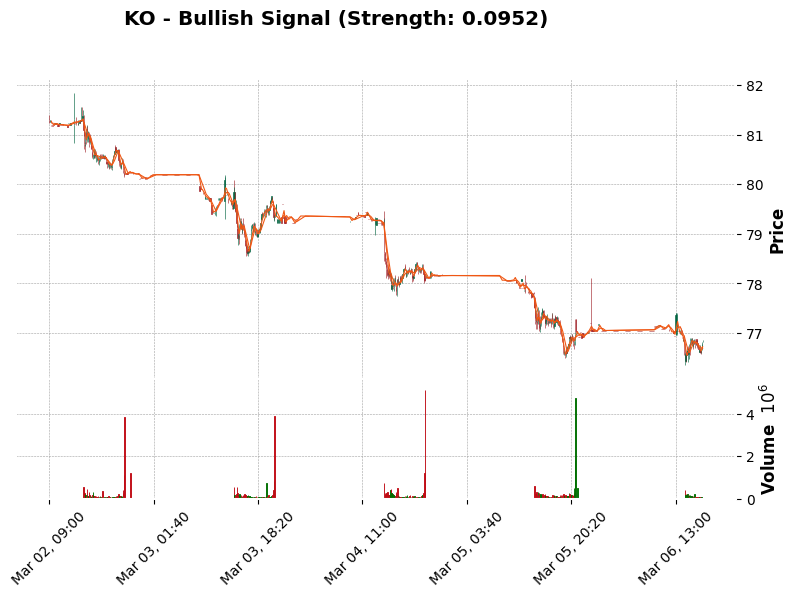

/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'

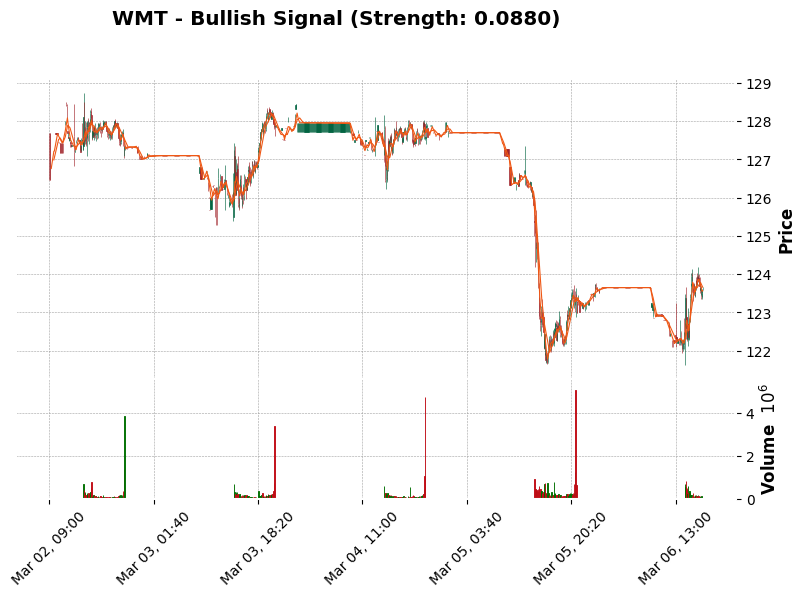

/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'

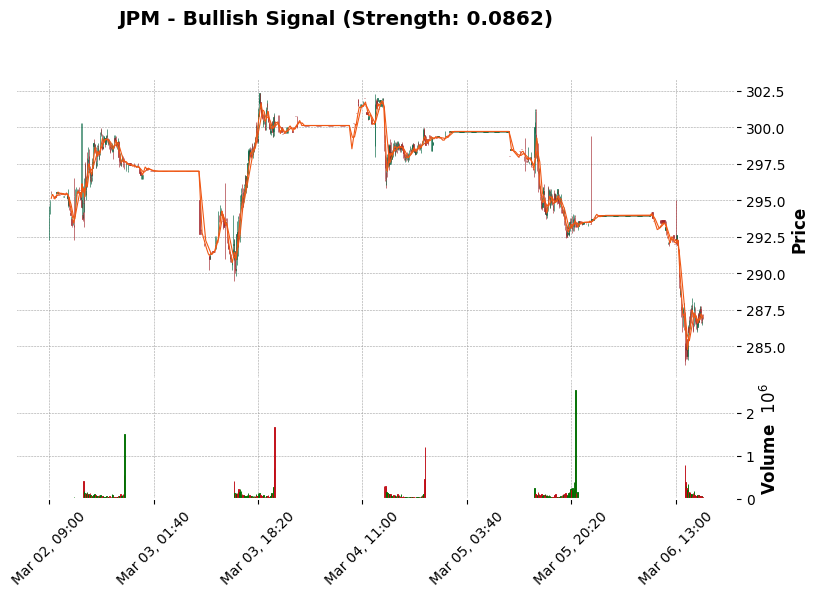


--- Visualizing Top Bearish Candidates ---


/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+
/usr/local/lib/python3.12/dist-packages/mplfinance/plotting.py:476: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.

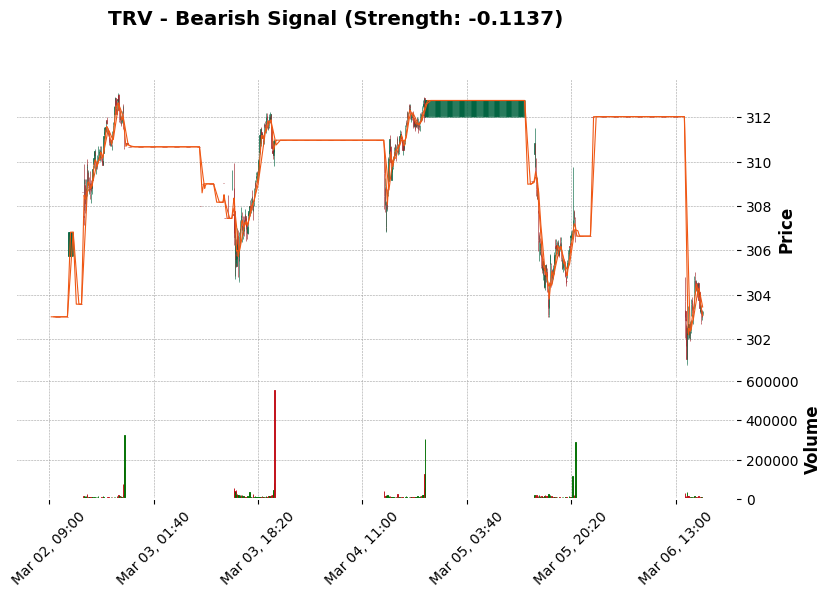

/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'

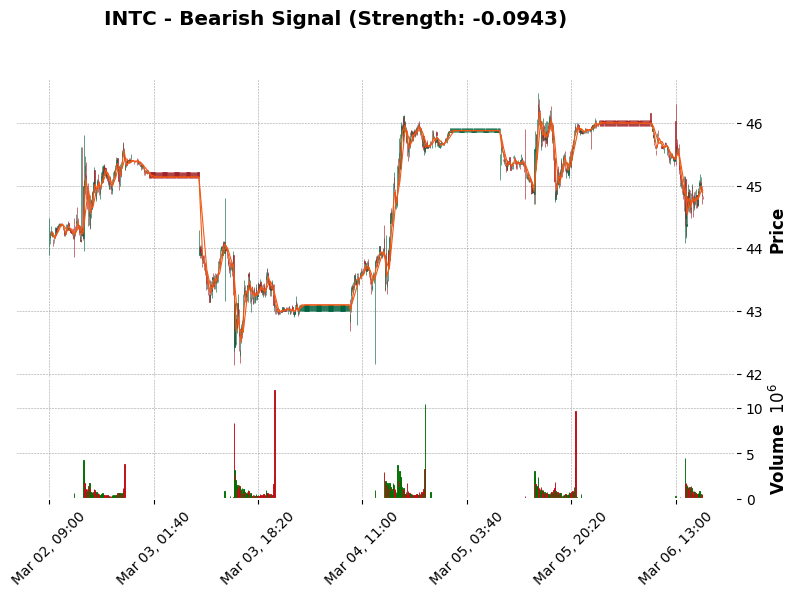

/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


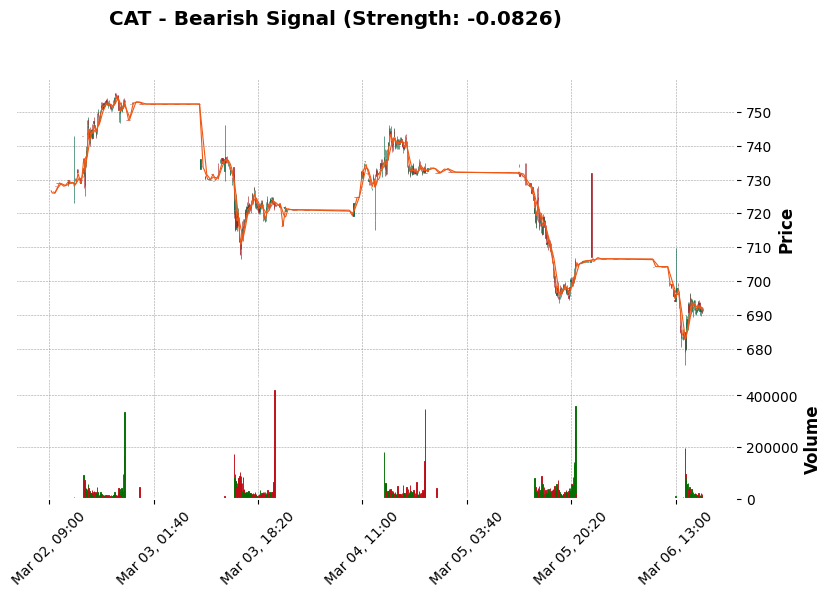

/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


In [63]:
%pip install mplfinance -q

import mplfinance as mpf
import pandas as pd
from IPython.display import display

def plot_top_candidates(df_data, candidates, sentiment_label):
    """
    Plots candlestick charts for the given list of candidate tickers.
    """
    print(f"\n--- Visualizing Top {sentiment_label} Candidates ---")

    for index, row in candidates.iterrows():
        ticker = row['ticker']
        strength = row['raw_strength']

        df_plot = df_data[df_data['tic'] == ticker].copy()

        if df_plot.empty:
            print(f"No data found for {ticker}")
            continue

        df_plot['date'] = pd.to_datetime(df_plot['date'])
        df_plot.set_index('date', inplace=True)

        plot_title = f"{ticker} - {sentiment_label} Signal (Strength: {strength:.4f})"


        fig, axlist = mpf.plot(df_plot,
                               type='candle',
                               style='charles',
                               title=plot_title,
                               volume=True,
                               mav=(5, 10),
                               figsize=(10, 6),
                               returnfig=True)

        display(fig)

if 'live_5m' in locals() and 'bullish' in locals() and 'bearish' in locals():
    plot_top_candidates(live_5m, bullish.head(3), "Bullish")

    plot_top_candidates(live_5m, bearish.head(3), "Bearish")
else:
    print("Error: Data from the inference step (live_5m, bullish, bearish) is missing. Please run the previous cell first.")